In [1]:
import sys
sys.executable

'/home/miguel/Python_Projects/Stats/stats/bin/python3.11'

In [2]:
import pandas as pd
import numpy as np
import math

data_path = '/home/miguel/Python_Projects/datasets/'
data = pd.read_csv(data_path + 'PlayTennis.csv')

In [4]:
def highlight(cell_value):
    '''
    Highlight yes / no values in the dataframe
    '''
    color_1 = 'background-color: pink;'
    color_2 = 'background-color: lightgreen;'
    
    if cell_value == 'no':
        return color_1
    elif cell_value == 'yes':
        return color_2  

data.style.map(highlight)\
    .set_properties(subset=data.columns, **{'width': '100px'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', 'lightgray'), ('border', '1px solid gray'),
                                                    ('font-weight', 'bold')]},
     {'selector': 'tr:hover', 'props': [('background-color', 'white'), ('border', '1.5px solid black')]}])

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [11]:
def find_entropy(data):
    """
    Returns the entropy of the class or features
    formula: - ∑ P(X)logP(X)
    """
    entropy = 0
    for i in range(data.nunique()):
        x = data.value_counts().iloc[i] / data.shape[0]
        entropy += (- x * math.log(x,2))
    return round(entropy,3)



def information_gain(data, data_):
    """
    Returns the information gain of the features
    """
    info = 0
    for i in range(data_.nunique()):
        df = data[data_ == data_.unique()[i]]
        w_avg = df.shape[0]/data.shape[0]
        entropy = find_entropy(df.play)
        x = w_avg * entropy
        info += x
    ig = find_entropy(data.play) - info
    return round(ig, 3)   



def entropy_and_infogain(datax, feature):
    """
    Grouping features with the same class and computing their 
    entropy and information gain for splitting
    """
    for i in range(data[feature].nunique()):
        df = datax[datax[feature]==data[feature].unique()[i]]
        if df.shape[0] < 1:
            continue
        
        display(df[[feature, 'play']].style.map(highlight)\
                .set_properties(subset=[feature, 'play'], **{'width': '80px'})\
                .set_table_styles([{'selector': 'th', 'props': [('background-color', 'lightgray'), 
                                                                ('border', '1px solid gray'), 
                                                                ('font-weight', 'bold')]},
                                   {'selector': 'td', 'props': [('border', '1px solid gray')]},
                                   {'selector': 'tr:hover', 'props': [('background-color', 'white'), 
                                                                      ('border', '1.5px solid black')]}]))
        
        print(f'Entropy of {feature} - {data[feature].unique()[i]} = {find_entropy(df.play)}')
    print(f'Information Gain for {feature} = {information_gain(datax, datax[feature])}')

#### Compute entropy for the entire dataset

In [12]:
print(f'Entropy of the entire dataset: {find_entropy(data.play)}')

Entropy of the entire dataset: 0.94


## Step 1
Calculate the Information Gain for each feature.

In [13]:
entropy_and_infogain(data, 'outlook')

,outlook,play
0,sunny,no
1,sunny,no
7,sunny,no
8,sunny,yes
10,sunny,yes


Entropy of outlook - sunny = 0.971


,outlook,play
2,overcast,yes
6,overcast,yes
11,overcast,yes
12,overcast,yes


Entropy of outlook - overcast = 0.0


,outlook,play
3,rainy,yes
4,rainy,yes
5,rainy,no
9,rainy,yes
13,rainy,no


Entropy of outlook - rainy = 0.971
Information Gain for outlook = 0.246


In [14]:
entropy_and_infogain(data, 'temp')

,temp,play
0,hot,no
1,hot,no
2,hot,yes
12,hot,yes


Entropy of temp - hot = 1.0


,temp,play
3,mild,yes
7,mild,no
9,mild,yes
10,mild,yes
11,mild,yes
13,mild,no


Entropy of temp - mild = 0.918


,temp,play
4,cool,yes
5,cool,no
6,cool,yes
8,cool,yes


Entropy of temp - cool = 0.811
Information Gain for temp = 0.029


In [15]:
entropy_and_infogain(data, 'humidity')

,humidity,play
0,high,no
1,high,no
2,high,yes
3,high,yes
7,high,no
11,high,yes
13,high,no


Entropy of humidity - high = 0.985


,humidity,play
4,normal,yes
5,normal,no
6,normal,yes
8,normal,yes
9,normal,yes
10,normal,yes
12,normal,yes


Entropy of humidity - normal = 0.592
Information Gain for humidity = 0.151


In [16]:
entropy_and_infogain(data, 'windy')

,windy,play
0,False,no
2,False,yes
3,False,yes
4,False,yes
7,False,no
8,False,yes
9,False,yes
12,False,yes


Entropy of windy - False = 0.811


,windy,play
1,True,no
5,True,no
6,True,yes
10,True,yes
11,True,yes
13,True,no


Entropy of windy - True = 1.0
Information Gain for windy = 0.048


Outlook has the highest Information Gain - 0.246, so it is used as the root node.
In Overcast every data belongs to same class (Yes), which makes it as leaf node.

Sunny and Rainy has different class (Yes & no). 
So we find the feature with maximum Information gain for sunny and rainy for further splitting.

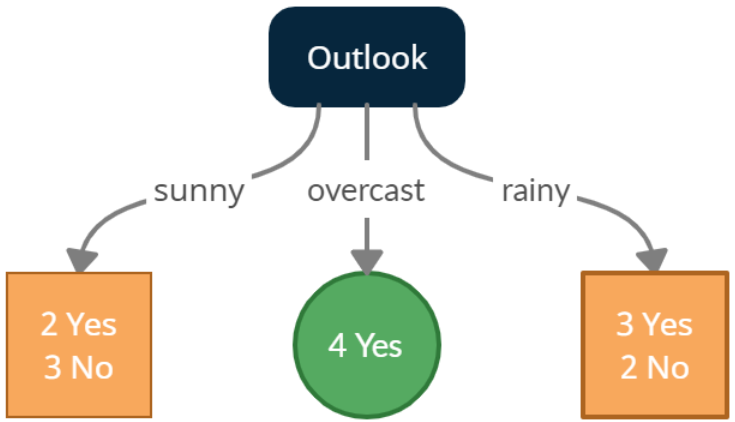

## Step 2
Repeat until we run out of all features, or the decision tree has all leaf nodes.


In [18]:
sunny = data[data['outlook'] == 'sunny']
sunny.style.map(highlight)\
    .set_properties(subset=data.columns, **{'width': '100px'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', 'lightgray'), ('border', '1px solid gray'),
                                                    ('font-weight', 'bold')]},
     {'selector': 'tr:hover', 'props': [('background-color', 'white'), ('border', '1.5px solid black')]}])

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
10,sunny,mild,normal,True,yes


In [19]:
print(f'Entropy of the Sunny dataset: {find_entropy(sunny.play)}')

Entropy of the Sunny dataset: 0.971


In [20]:
sunny.play

0      no
1      no
7      no
8     yes
10    yes
Name: play, dtype: object

In [21]:
entropy_and_infogain(sunny, 'temp')

,temp,play
0,hot,no
1,hot,no


Entropy of temp - hot = 0.0


,temp,play
7,mild,no
10,mild,yes


Entropy of temp - mild = 1.0


,temp,play
8,cool,yes


Entropy of temp - cool = 0.0
Information Gain for temp = 0.571


In [22]:
entropy_and_infogain(sunny, 'humidity')

,humidity,play
0,high,no
1,high,no
7,high,no


Entropy of humidity - high = 0.0


,humidity,play
8,normal,yes
10,normal,yes


Entropy of humidity - normal = 0.0
Information Gain for humidity = 0.971


In [23]:
entropy_and_infogain(sunny, 'windy')

,windy,play
0,False,no
7,False,no
8,False,yes


Entropy of windy - False = 0.918


,windy,play
1,True,no
10,True,yes


Entropy of windy - True = 1.0
Information Gain for windy = 0.02


#### Making a decision tree node using the feature which has the maximum Information Gain.
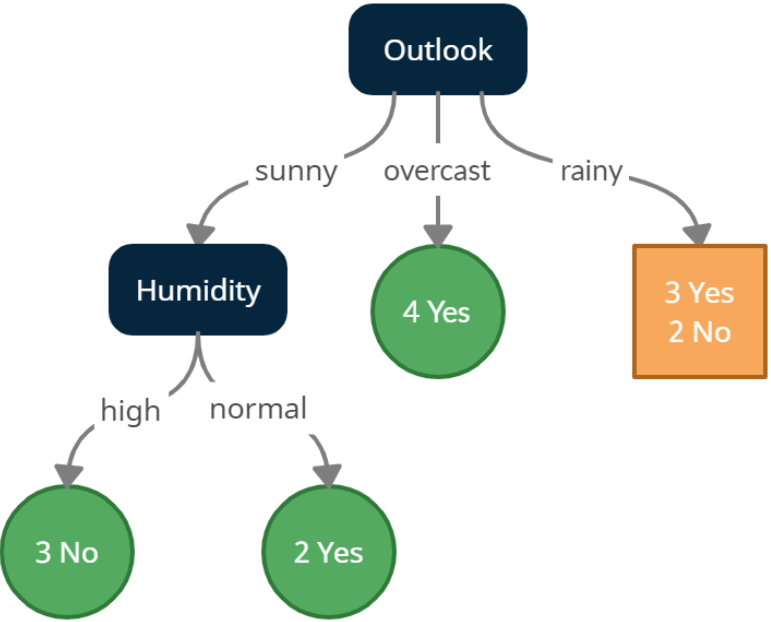


Humidity has the highest Information Gain - 0.971, so it is used as the decision node.
In Overcast and Humidity - high, normal every data classified to same class, which makes them as leaf node.
Now, only Rainy has different class (Yes & no). So again we find the feature with maximum Information gain for and rainy for further splitting.


In [24]:
rainy = data[data['outlook'] == 'rainy'] 
rainy.style.map(highlight)\
    .set_properties(subset=data.columns, **{'width': '100px'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', 'lightgray'), ('border', '1px solid gray'),
                                                    ('font-weight', 'bold')]},
     {'selector': 'tr:hover', 'props': [('background-color', 'white'), ('border', '1.5px solid black')]}])

,outlook,temp,humidity,windy,play
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
9,rainy,mild,normal,False,yes
13,rainy,mild,high,True,no


In [25]:
print(f'Entropy of the Rainy dataset: {find_entropy(rainy.play)}')

Entropy of the Rainy dataset: 0.971


In [27]:
entropy_and_infogain(rainy, 'temp')

,temp,play
3,mild,yes
9,mild,yes
13,mild,no


Entropy of temp - mild = 0.918


,temp,play
4,cool,yes
5,cool,no


Entropy of temp - cool = 1.0
Information Gain for temp = 0.02


In [28]:
entropy_and_infogain(rainy, 'humidity')

,humidity,play
3,high,yes
13,high,no


Entropy of humidity - high = 1.0


,humidity,play
4,normal,yes
5,normal,no
9,normal,yes


Entropy of humidity - normal = 0.918
Information Gain for humidity = 0.02


In [29]:
entropy_and_infogain(rainy, 'windy')

,windy,play
3,False,yes
4,False,yes
9,False,yes


Entropy of windy - False = 0.0


,windy,play
5,True,no
13,True,no


Entropy of windy - True = 0.0
Information Gain for windy = 0.971


#### Making a decision tree node using the feature which has the maximum Information Gain.

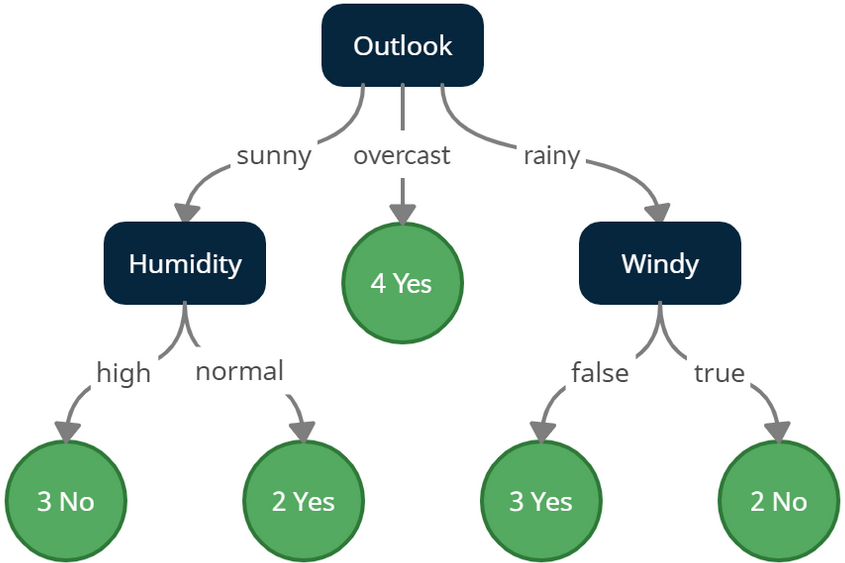

Windy has the highest Information Gain - 0.971, so it is used as the decision node.
This decision tree has all leaf node.